In [1]:
import sys
sys.path.append('../')

import re
import numpy as np
import pandas as pd
import pyvinecopulib as pv
import seaborn as sns
import matplotlib.pyplot as plt

import json

from utils.analyse_results import *

### Read AIA results

In [2]:
# Read AIA results
with open('../tests_simulated_data/inference/runconfig.json') as file:
        runconfig = json.load(file)

# Read regression coefficients from AIA game
regCoeff = pd.read_csv("../tests_simulated_data/inference/reg_coeff_dict_keys(['x1', 'x6', 'x12']).csv")

# Parameters
d = regCoeff.shape[1] - 3
nIter = runconfig['nIter']
nSynT = runconfig['nSynT']

CVCDA(20)
IMRV(0.25, 20)
IMRV(0.5, 20)
IMRV(0.75, 20)
CvineSensitive(5, 20)
Cvine(1)
Cvine(5)
Cvine(10)
Cvine(15)
Cvine(20)
PrivBayes(0.1)
PrivBayes(1.0)
PrivBayes(5.0)
CTGAN(1000, 500)
TVAE(1500, 400)
PrivPGD(2.5, 1e-05)


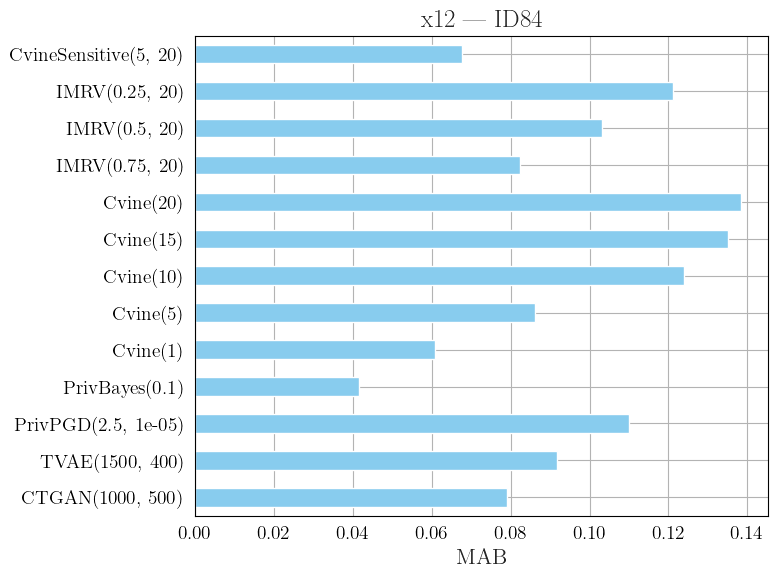

In [3]:
sa = "x12"
tid = "ID84"
MAB = []
for gm in regCoeff.genModel.unique():
    print(gm)
    df = regCoeff.loc[(regCoeff["sa"]==sa) & (regCoeff["tid"] == tid) & (regCoeff["genModel"]==gm),]
    mab = df[df.columns[range(d)]].abs().sum().sum()/(d*df.shape[0])
    MAB.append(mab)

coefficients = [f"b{i}" for i in range(d)]
MAB = regCoeff.groupby(['sa', 'tid', 'genModel'])[coefficients].apply(lambda x: x.abs().to_numpy().sum()/(d*nIter*nSynT))
MAB.name = "MAB"

sub = MAB.loc[(sa,tid)]
order = [
    'CTGAN(1000, 500)',
    'TVAE(1500, 400)', 
    'PrivPGD(2.5, 1e-05)',
    'PrivBayes(0.1)',
    'Cvine(1)',
    'Cvine(5)',
    'Cvine(10)',
    'Cvine(15)', 
    'Cvine(20)', 
    'IMRV(0.75, 20)',
    'IMRV(0.5, 20)',
    'IMRV(0.25, 20)',
    'CvineSensitive(5, 20)',
]
sub = sub.reindex(order)
ax = sub.plot.barh(figsize=(8, 6))
ax.set_xlabel("MAB")
ax.set_ylabel("")
ax.set_title(f"{sa} — {tid}")
plt.tight_layout()
plt.show()

### Read utility results

In [4]:
with open('../tests_simulated_data/utility/utility_metrics_real_data.json') as file:
        utility_metrics = json.load(file)
# utility_metrics = pd.DataFrame(utility_metrics)

In [5]:
auc = {}
for gm in utility_metrics.keys():
    auc[gm] = utility_metrics[gm]['AUC-ROC']
auc = pd.DataFrame(auc)

In [6]:
utility = auc.mean()
utility.name = "AUC-ROC"
utility

Raw                      0.997192
CVCDA(20)                0.995989
IMRV(0.25, 20)           0.877681
IMRV(0.5, 20)            0.876064
IMRV(0.75, 20)           0.887065
CvineSensitive(5, 20)    0.937534
Cvine(1)                 0.885786
Cvine(5)                 0.881400
Cvine(10)                0.925699
Cvine(15)                0.932413
Cvine(20)                0.931532
PrivBayes(0.1)           0.499063
PrivBayes(1.0)           0.529071
PrivBayes(5.0)           0.558718
CTGAN(1000, 500)         0.738989
TVAE(1500, 400)          0.977753
PrivPGD(2.5, 1e-05)      0.521987
Name: AUC-ROC, dtype: float64

### Make privacy utility plots

In [7]:
privacy_utility_df = pd.concat([utility, MAB.loc[(sa, tid)]], axis=1)

In [8]:
df = privacy_utility_df

In [9]:
df

,AUC-ROC,MAB
Raw,0.997192,NaN
CVCDA(20),0.995989,0.128177
"IMRV(0.25, 20)",0.877681,0.121144
"IMRV(0.5, 20)",0.876064,0.103109
"IMRV(0.75, 20)",0.887065,0.082253
"CvineSensitive(5, 20)",0.937534,0.067635
Cvine(1),0.885786,0.060891
Cvine(5),0.881400,0.086035
Cvine(10),0.925699,0.123937
Cvine(15),0.932413,0.135171


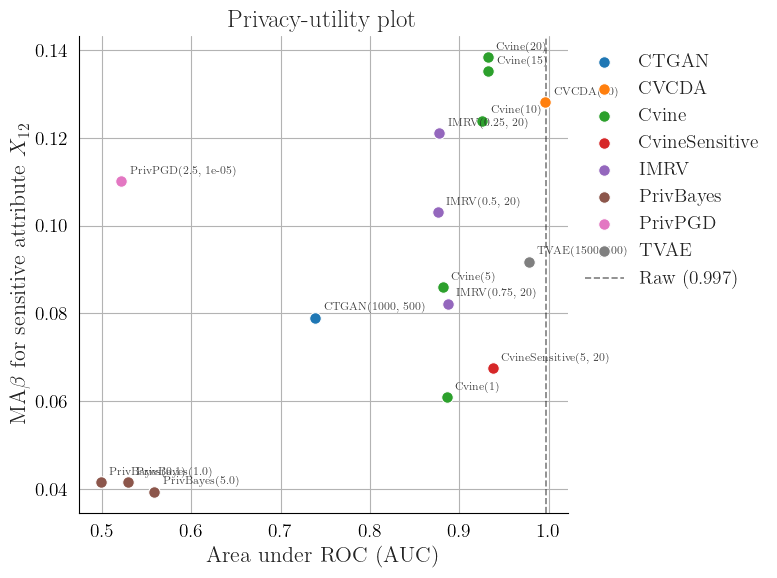

In [10]:
# df: index = model names, columns = ['AUC-ROC', 'MAB']

def short_name(s):
    m = re.match(r'([^(]+)\((.*)\)', s)
    if not m:
        return s, s
    family, args = m.group(1), m.group(2)
    nums = re.findall(r'=\s*([\d.]+)', args)          # "trunc_lvl=15" -> "15"
    return family, f"{family} ({', '.join(nums)})" if nums else family

raw_auc = df.loc['Raw', 'AUC-ROC']
plot_df = df.drop(index='Raw').copy()

families, labels = zip(*[short_name(i) for i in plot_df.index])
plot_df['family'], plot_df['label'] = families, labels

fig, ax = plt.subplots(figsize=(8, 6))

palette = dict(zip(sorted(set(families)), plt.cm.tab10.colors))
for fam, sub in plot_df.groupby('family'):
    ax.scatter(sub['AUC-ROC'], sub['MAB'], s=70, color=palette[fam],
               edgecolor='white', linewidth=0.8, label=fam, zorder=3)

ax.axvline(raw_auc, color='black', linestyle='--', linewidth=1.2, zorder=2,
           label=f'Raw ({raw_auc:.3f})', alpha=0.5)

for _, r in plot_df.iterrows():
    ax.annotate(r.name, (r['AUC-ROC'], r['MAB']),
                textcoords='offset points', xytext=(6, 5),
                fontsize=8, alpha=0.85)

ax.set_xlabel('Area under ROC (AUC)')
ax.set_ylabel(r'MA$\beta$ for sensitive attribute $X_{12}$')
ax.set_title('Privacy-utility plot')
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.0, 1.0))
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

# Read MIA results

In [11]:
dirname = '../tests_simulated_data/linkage/'
linkage_gain = load_results_linkage(dirname)

In [12]:
linkage_gain.TargetModel.unique()

array(['CTGAN(1000, 500)', 'CVCDA(20)', 'Cvine(1)', 'Cvine(10)',
       'Cvine(15)', 'Cvine(20)', 'Cvine(5)', 'CvineSensitive(5, 20)',
       'IMRV(0.25, 20)', 'IMRV(0.5, 20)', 'IMRV(0.75, 20)',
       'PrivBayes(0.1)', 'PrivBayes(1.0)', 'PrivBayes(5.0)',
       'PrivPGD(2.5, 1e-05)', 'TVAE(1500, 400)'], dtype=object)

In [13]:
models = ['CTGAN(1000, 500)', 'CVCDA(20)', 'Cvine(1)', 'Cvine(10)',
       'Cvine(15)', 'Cvine(20)', 'Cvine(5)', 'CvineSensitive(5, 20)',
       'IMRV(0.25, 20)', 'IMRV(0.5, 20)', 'IMRV(0.75, 20)',
       'PrivBayes(0.1)', 'PrivBayes(1.0)', 'PrivBayes(5.0)',
       'PrivPGD(2.5, 1e-05)', 'TVAE(1500, 400)']
# fig = plt_per_target_pg(linkage_gain, models, resFilter=('FeatureSet', 'Correlations'))

In [14]:
linkage_gain.FeatureSet.unique()

array(['Correlations', 'Histogram', 'Naive'], dtype=object)

In [15]:
mia_results = linkage_gain.loc[linkage_gain.FeatureSet=="Correlations",].drop("FeatureSet", axis=1)

In [16]:
mia_results

,TargetID,TargetModel,Run,TPSyn,FPSyn,AdvantageSyn,AdvantageRaw,PrivacyGain
0,ID447,"CTGAN(1000, 500)",0,0.52,0.88,-0.36,1,1.36
1,ID447,"CTGAN(1000, 500)",1,0.60,0.22,0.38,1,0.62
2,ID447,"CTGAN(1000, 500)",2,0.04,0.84,-0.80,1,1.80
3,ID447,"CTGAN(1000, 500)",3,0.88,0.06,0.82,1,0.18
4,ID447,"CTGAN(1000, 500)",4,0.34,0.22,0.12,1,0.88
...,...,...,...,...,...,...,...,...
935,ID84,"TVAE(1500, 400)",5,1.00,0.00,1.00,1,0.00
936,ID84,"TVAE(1500, 400)",6,1.00,0.00,1.00,1,0.00
937,ID84,"TVAE(1500, 400)",7,1.00,0.00,1.00,1,0.00
938,ID84,"TVAE(1500, 400)",8,1.00,0.00,1.00,1,0.00


In [17]:
mia_results_ID447 = mia_results.loc[mia_results.TargetID == "ID447",].drop(["TargetID","Run", "TPSyn", "FPSyn", "AdvantageSyn", "AdvantageRaw"], axis=1)
mia_results_ID84 = mia_results.loc[mia_results.TargetID == "ID84",].drop(["TargetID","Run", "TPSyn", "FPSyn", "AdvantageSyn", "AdvantageRaw"], axis=1)

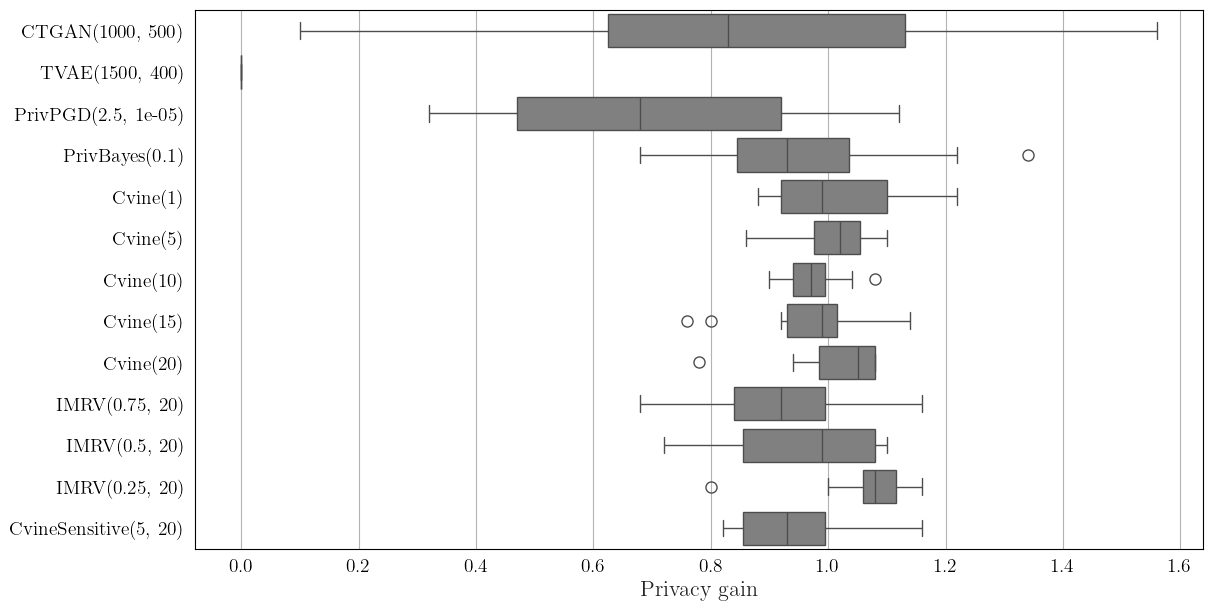

In [18]:
plt.figure()
sns.boxplot(data=mia_results_ID84,
            y="TargetModel",
            x="PrivacyGain",
            color="grey",
            order=order)
plt.xlabel("Privacy gain")
plt.ylabel("")
plt.show()

In [19]:
linkage_gain.loc[linkage_gain.FeatureSet=="Correlations",].drop("FeatureSet", axis=1).loc[linkage_gain.TargetModel=="TVAE(1500, 400)",]

,TargetID,TargetModel,Run,TPSyn,FPSyn,AdvantageSyn,AdvantageRaw,PrivacyGain
450,ID447,"TVAE(1500, 400)",0,1.00,0.0,1.00,1,0.00
451,ID447,"TVAE(1500, 400)",1,1.00,0.0,1.00,1,0.00
452,ID447,"TVAE(1500, 400)",2,1.00,0.0,1.00,1,0.00
453,ID447,"TVAE(1500, 400)",3,1.00,0.0,1.00,1,0.00
454,ID447,"TVAE(1500, 400)",4,1.00,0.0,1.00,1,0.00
455,ID447,"TVAE(1500, 400)",5,1.00,0.0,1.00,1,0.00
456,ID447,"TVAE(1500, 400)",6,1.00,0.0,1.00,1,0.00
457,ID447,"TVAE(1500, 400)",7,1.00,0.0,1.00,1,0.00
458,ID447,"TVAE(1500, 400)",8,1.00,0.0,1.00,1,0.00
459,ID447,"TVAE(1500, 400)",9,0.94,0.0,0.94,1,0.06
